In [15]:
#import libraries

#image management
from photutils.aperture import EllipticalAperture
from photutils.aperture import EllipticalAnnulus
from photutils.aperture import aperture_photometry
from photutils.centroids import centroid_com
from astropy.nddata import Cutout2D
from photutils.segmentation import detect_sources
from astropy.visualization import ZScaleInterval, ImageNormalize
from photutils.background import Background2D, MedianBackground

#plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.cbook as cbook
from matplotlib_scalebar.scalebar import ScaleBar

#astro handeling
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import pyregion
import sep

#math
import numpy as np
from astropy.visualization import simple_norm
from astropy.stats import SigmaClip

#data frame handeling
import pandas as pd

#pdf handeling
from matplotlib.backends.backend_pdf import PdfPages

#exception handeling
import warnings
warnings.simplefilter('ignore')

#lab handeling
from IPython.display import clear_output
import time

#custom stuff
import Galaxy_info as gi
import utils

In [2]:
#galaxies
galaxy_id = ["WLM", "IC 10", "NGC 4214", "UGC 8508", "DDO 50", "DDO 53"]

#file data
file = gi.Galaxy_Info[galaxy_id[0]]

#galaxy name
galaxy = file[0]

#hi file
hi_fits = file[1]

#ha file
ha_fits = file[2]

#ha csv file
ha_csv = file[3]

#irac file
irac_fits = file[4]

#irac csv file
irac_csv = file[5]

#region file
region_file = file[6]

#distance to galxy kpc
distance = file[7]

In [3]:
#load image
#open ha fits file
hdu_ha = fits.open(ha_fits)

#read in ha header
header_ha = hdu_ha[0].header

#read in ha image as numpy array
ha_image = hdu_ha[0].data

#correct ha image for noise
masked_ha = utils.subtract_noise(ha_image)#utils.mask_stars(ha_image)

#read in ha wcs data
wcs_ha = WCS(header_ha)

#read in ha pixel to arcsec conversion
cdelt = "CD2_2" if "CD2_2" in header_ha else "CDELT2"
arcsec_per_pixel_ha = np.abs(header_ha[cdelt]) * 3600

#get ha flux units
try:
    unit_ha = (10**header_ha["RESPONSE"])
except:
    unit_ha = 1

In [25]:
#load region

#region index
index = 0

#read in regions
regions = pyregion.open(region_file)

print(regions)

#read in region
region = regions[index]

#load region characteristics

#grab coords of region center - coord_list: [RA, Dec, a_arcsec, b_arcsec, PA]
ra, dec, a_arcsec, b_arcsec, pa_deg = region.coord_list

#convert region center to pixel
skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
x_ha, y_ha = skycoord.to_pixel(wcs_ha)

#convert to rads
theta = np.deg2rad(pa_deg)
print(ra, dec, pa_deg)

#convert ha arcsec → pixels
a_pix_ha = a_arcsec * 3600/ arcsec_per_pixel_ha
b_pix_ha = b_arcsec * 3600/ arcsec_per_pixel_ha

#convert region center to pixel
skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
x_ha, y_ha = skycoord.to_pixel(wcs_ha)

[Shape : ellipse ( HMS(00:01:56.1),DMS(-15:28:57.0),Ang(10.83"),Ang(7.58"),Number(94) ), Shape : ellipse ( HMS(00:01:58.5),DMS(-15:27:41.8),Ang(19.49"),Ang(17.54"),Number(139) ), Shape : ellipse ( HMS(00:01:58.9),DMS(-15:28:49.5),Ang(10.52"),Ang(10.52"),Number(90) ), Shape : ellipse ( HMS(00:02:03.7),DMS(-15:31:12.0),Ang(27.64"),Ang(27.64"),Number(90) )]
0.48375 -15.4825 94.0


In [26]:
#generate cutout
try:
    cutout, z = utils.cut_mark_image((x_ha, y_ha), a_pix_ha, b_pix_ha, theta, masked_ha)
except Exception as e:
    print(e)

In [27]:
#initialize zscale
zscale = ZScaleInterval()

In [28]:
#generate flux data
radii_ha, flux_ha, rim_core_ha = utils.sum_core_to_rim_pix((x_ha, y_ha), a_pix_ha/b_pix_ha, theta, masked_ha, \
                                                         arcsec_per_pixel_ha, a_pix_ha)
        
                
#convert radii to kpc
radii_ha = utils.arcsecs_to_radius(radii_ha, distance)

#convert flux to erg/s/cm^2/A
flux_ha = flux_ha * unit_ha

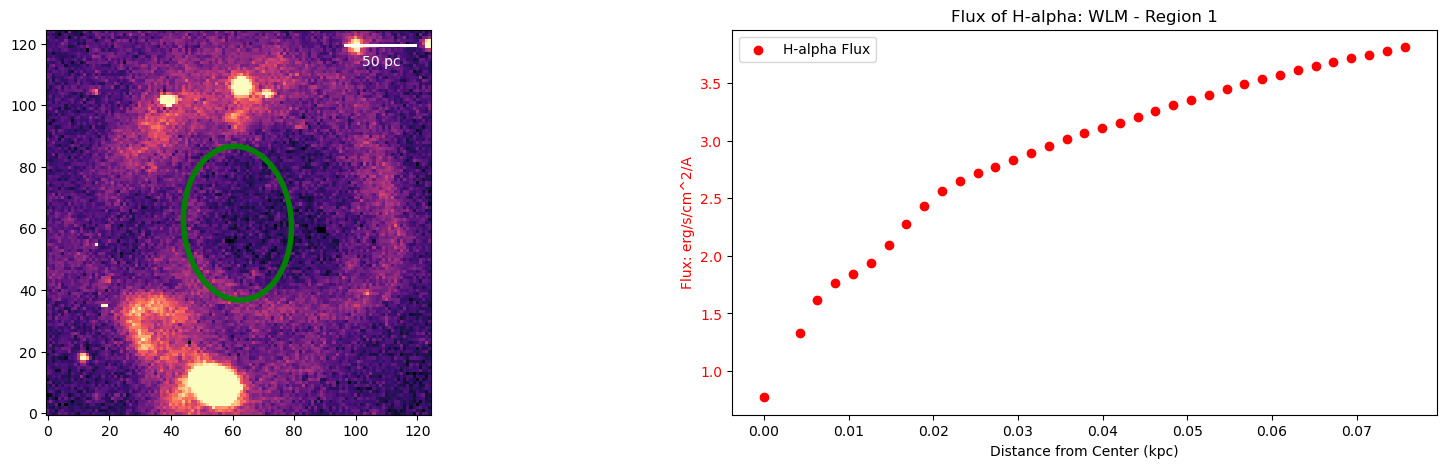

In [32]:
#intialize frames
stop = 2
frames = len(radii_ha)

#iterate frames
for frame in range(0, frames + 1):

    #initialize figure
    fig, axs = plt.subplots(1, 2, figsize=(20, 5))

    #generate ellipse scale
    ellipse_scale = (frame / frames) * stop

    #print(ellipse_scale)

    #generate cutout and ellipse
    cutout, ellipse = utils.cut_mark_image((x_ha, y_ha), a_pix_ha, b_pix_ha, theta, masked_ha, ellipse_scale)

    #plot cutout and ellipse
    vmin, vmax = zscale.get_limits(cutout)
    axs[0].imshow(cutout, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
    
    #plot region ellipse
    axs[0].add_patch(ellipse)

    #add scalebar to cutout
    scalebar = ScaleBar(utils.arcsecs_to_radius(arcsec_per_pixel_ha, distance), units='kpc', dimension="astro-length", border_pad=.8, box_alpha=0, color='w')
    axs[0].add_artist(scalebar)

    #plot core to rim
    utils.plot_core_rim_one(radii_ha[:frame], flux_ha[:frame], axs, galaxy, index, unit_ha, ax=1)

    #show plot
    plt.show()

    clear_output(wait=True)
    time.sleep(.2)

